In [1]:
import csv
import random

# Define the weather conditions and their corresponding temperature and humidity ranges
weather_conditions = {
    'Sunny': {'temperature_range': (20, 35), 'humidity_range': (30, 60)},
    'Cloudy': {'temperature_range': (15, 25), 'humidity_range': (50, 80)},
    'Rainy': {'temperature_range': (10, 25), 'humidity_range': (70, 100)},
    'Snowy': {'temperature_range': (-10, 5), 'humidity_range': (50, 90)}
}

# Define the number of rows to generate in the CSV file
num_rows = 100

# Generate the fake dataset and write it to a CSV file
with open('weather_dataset.csv', 'w', newline='') as file:
    writer = csv.writer(file)

    # Write the header row
    writer.writerow(['Weather', 'Temperature (°C)', 'Humidity (%)'])

    # Generate random weather conditions, temperature, and humidity values for each row
    for _ in range(num_rows):
        weather = random.choice(list(weather_conditions.keys()))
        temperature_range = weather_conditions[weather]['temperature_range']
        humidity_range = weather_conditions[weather]['humidity_range']
        temperature = random.uniform(temperature_range[0], temperature_range[1])
        humidity = random.uniform(humidity_range[0], humidity_range[1])
        writer.writerow([weather, round(temperature, 2), round(humidity, 2)])

print("Fake dataset generated successfully!")

Fake dataset generated successfully!


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Load the dataset from the CSV file
dataset = pd.read_csv('weather_dataset.csv')

print(dataset.head())

print("----------------------------------------")

# Perform data preprocessing
# Convert categorical weather conditions to numerical labels
dataset['Weather'] = dataset['Weather'].astype('category')
dataset['Weather'] = dataset['Weather'].cat.codes

dataset.head()

  Weather  Temperature (°C)  Humidity (%)
0   Sunny             20.88         36.87
1  Cloudy             21.18         62.69
2  Cloudy             15.94         76.78
3   Sunny             20.12         56.11
4   Sunny             23.18         42.29
----------------------------------------


,Weather,Temperature (°C),Humidity (%)
0,3,20.88,36.87
1,0,21.18,62.69
2,0,15.94,76.78
3,3,20.12,56.11
4,3,23.18,42.29


In [2]:
# Split the dataset into input features (temperature, humidity) and target variable (weather conditions)
X = dataset[['Temperature (°C)', 'Humidity (%)']]
y = dataset['Weather']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.21, random_state=42)

# Create a decision tree classifier model
model = DecisionTreeClassifier()

# Train the model on the training data
model.fit(X_train, y_train)

# Make predictions on the testing data
y_pred = model.predict(X_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy}")


Model Accuracy: 0.9047619047619048


In [4]:
import pickle

# save the iris classification model as a pickle file
model_pkl_file = "weaather_model.pkl"  

with open(model_pkl_file, 'wb') as file:  
    pickle.dump(model, file)

In [36]:
def weather_prediction(data):
    weather = {0: "Cloudy", 1:"Rainy", 2:"Snowy", 3:"Sunny"}
    predicted_weather = model.predict(data)
    print(f"Predicted Weather: {weather[predicted_weather[0]]}")

In [37]:
# Example usage: Predict weather conditions for a given temperature and humidity
weather_prediction([[30, 50]])

Predicted Weather: Sunny


c:\Users\hp\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning:

X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names



In [4]:
import plotly.graph_objects as go

data = go.Scatter(x=X['Temperature (°C)'], y=X['Humidity (%)'])
fig = go.Figure(data=data)

fig.layout.title = 'Weather Conditions'
fig.layout.xaxis.title = 'Temperature (°C)'
fig.layout.yaxis.title = 'Humidity (%)'

fig


# Visualize the data and decision boundary
# plt.plot(X['Temperature (°C)'], X['Humidity (%)'], c=y, cmap='viridis')
# plt.xlabel('Temperature (°C)')
# plt.ylabel('Humidity (%)')
# plt.title('Weather Conditions')
# plt.show()

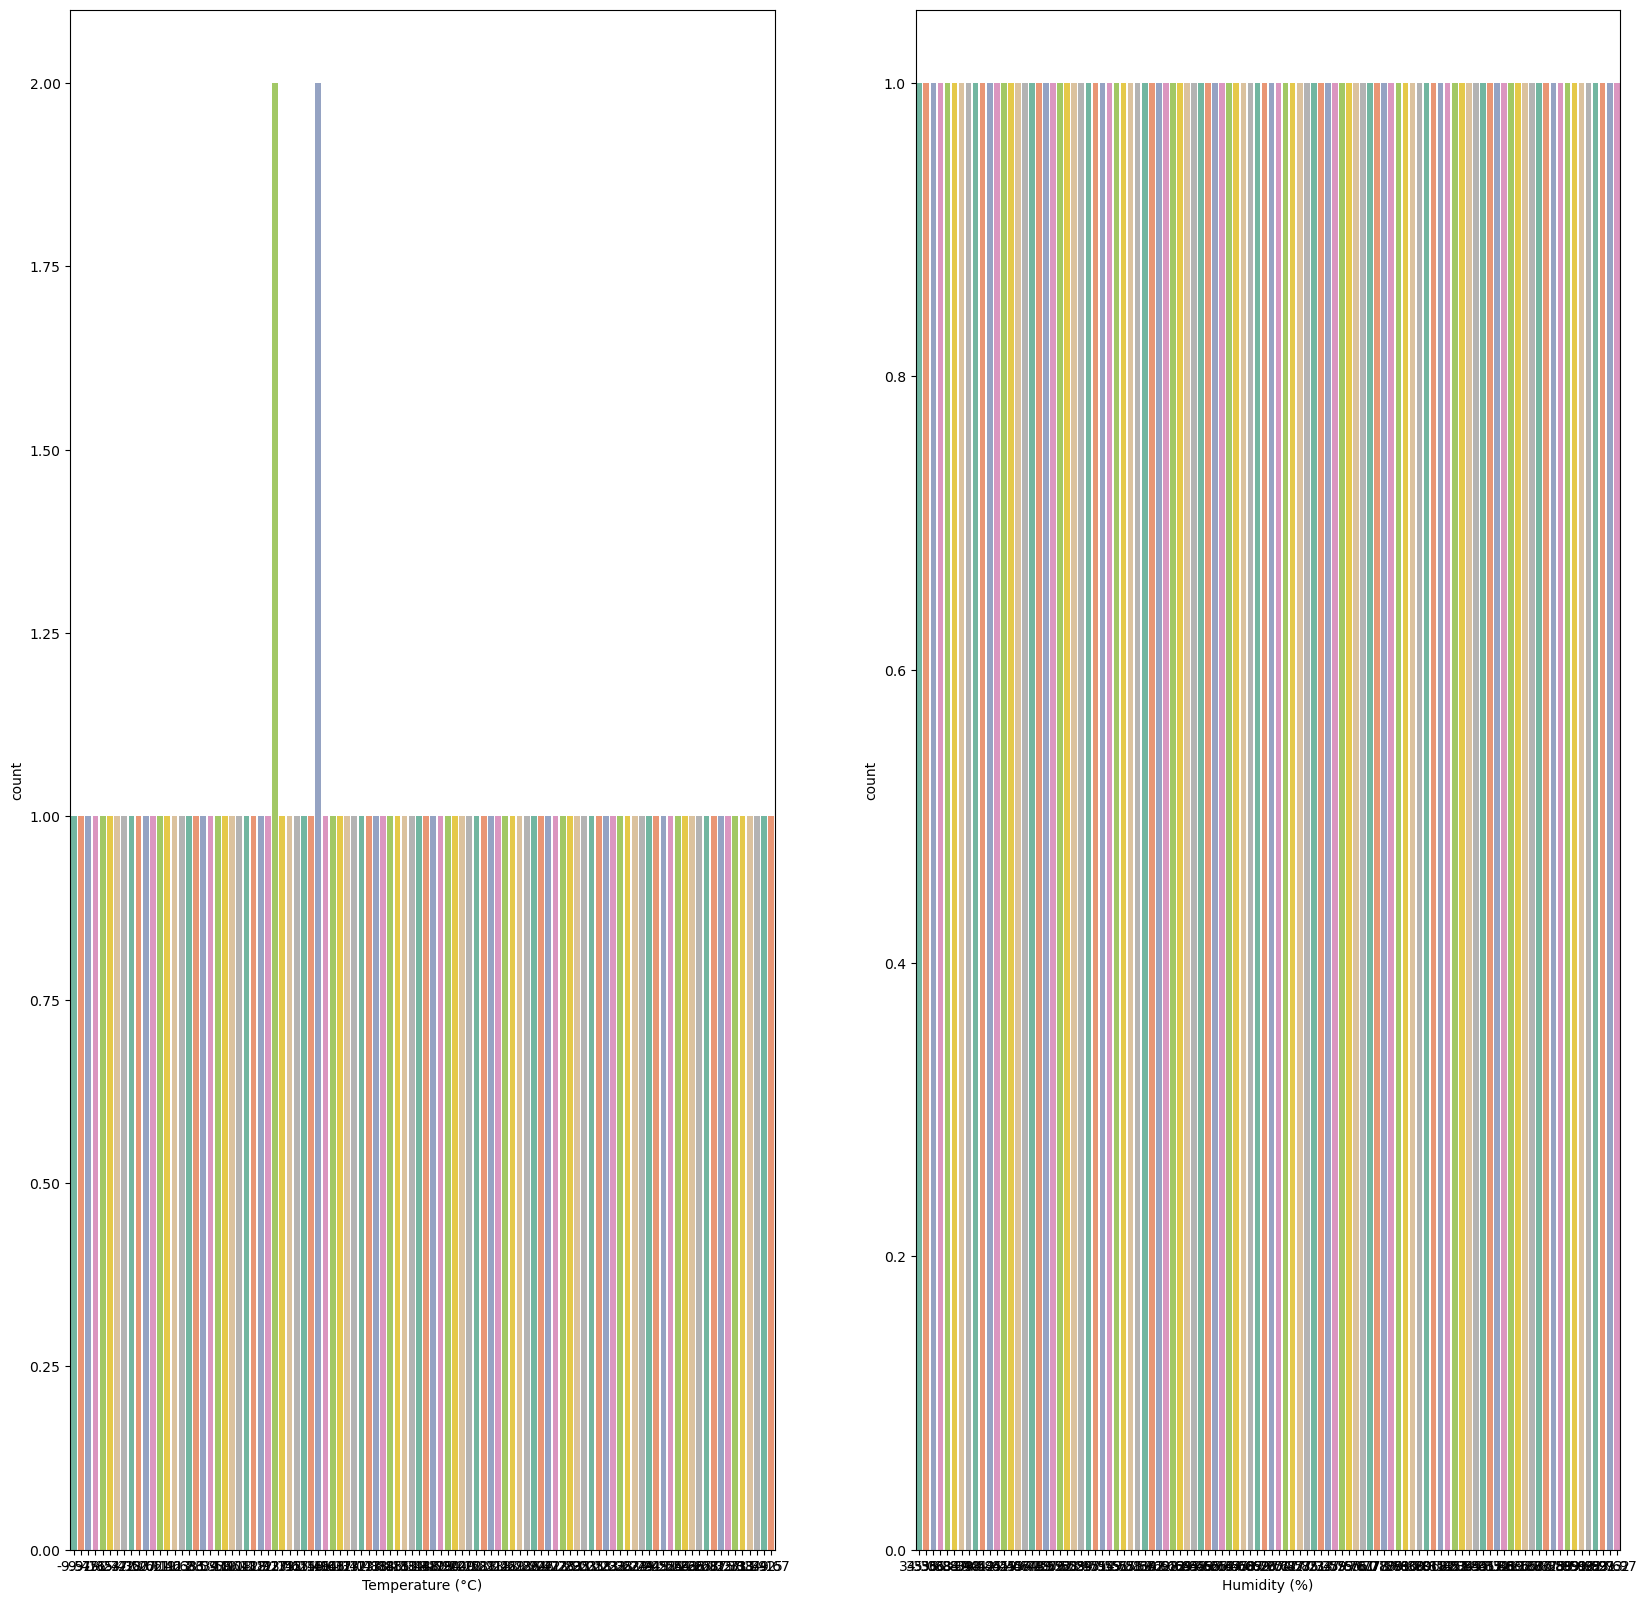

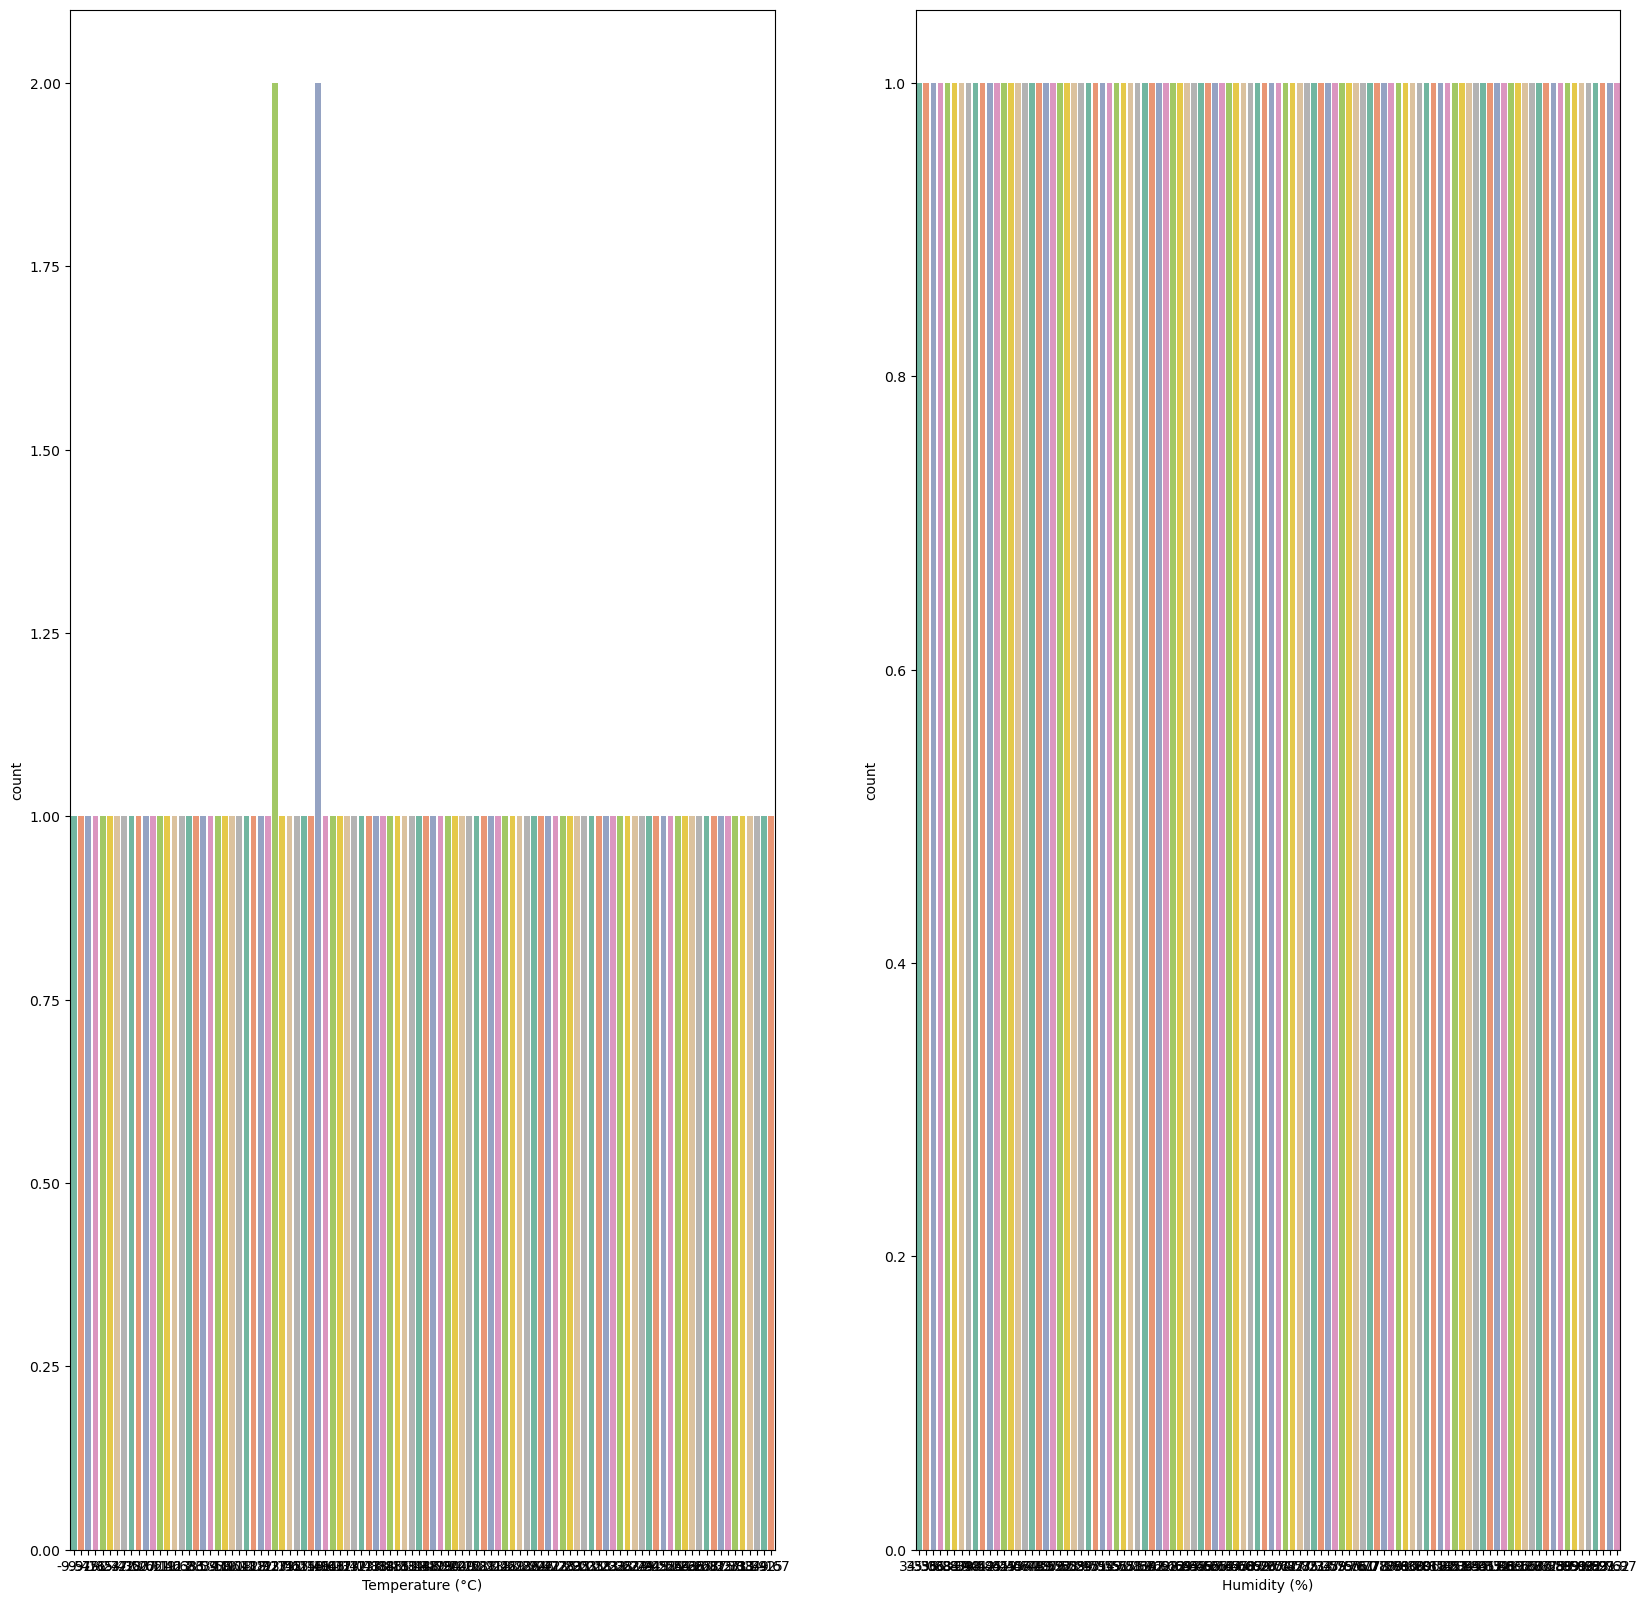

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(20, 20))
plt.subplot(1,2,1)
sns.countplot(x = 'Temperature (°C)', palette='Set2', data = X)
plt.subplot(1,2,2)
sns.countplot(x = 'Humidity (%)', palette='Set2', data = X)


fig